In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## First Inspection
- Data Visualisation 
- Dataset Loading



In [2]:
sns.set_theme(style="whitegrid")

In [3]:
import requests
url = "https://raw.githubusercontent.com/Elham-Schojaei/Techlab_Data_Science_Team3/d349ebcddfa64b667b9113a5348ce1771ab33bc9/data/processed/final_dataset.csv"

response = requests.get(url)
response.raise_for_status()

with open("final_dataset.csv", "wb") as f:
    f.write(response.content)


print("\nBasic Exploratory Data Analysis: \n")
data = pd.read_csv("final_dataset.csv")


Basic Exploratory Data Analysis: 



In [4]:
print(data.head())
print("\nShape:", data.shape)
print("\nColumns:")
print(data.columns)
print("\nInfo:")
print(data.info())
print("\nMissing values:")
print(data.isna().sum())

            id            created_at  width  height  likes    color  \
0  IicyiaPYGGI  2016-06-05T17:07:21Z   4928    3264  10099  #f3f3f3   
1  EwKXn5CapA4  2018-02-13T04:33:34Z   3648    5472  16755  #26260c   
2  1Z2niiBPg5A  2016-08-01T17:13:04Z   7372    4392   5795  #404040   
3  UCd78vfC8vU  2016-08-28T15:26:50Z   3634    5998   4613  #d9f3f3   
4  cssvEZacHvQ  2015-05-31T15:42:52Z   4000    6000   4248  #405926   

                                     alt_description       username  \
0                                     orange flowers       henry_be   
1        sun light passing through green leafed tree   jeremybishop   
2                              foggy mountain summit          v2osk   
3           two brown deer beside trees and mountain   thejoltjoker   
4  gray concrete bridge and waterfalls during day...  blakeverdoorn   

                                           image_url  brightness    sharpness  
0  https://images.unsplash.com/photo-146514634442...  208.808395  

## First Engagement Analysis (likes)

In [5]:
print("\nSummary statistics for likes:")
print(data["likes"].describe())


Summary statistics for likes:
count     1006.000000
mean      2498.759443
std       2550.429328
min          0.000000
25%        810.500000
50%       1749.500000
75%       3387.000000
max      19493.000000
Name: likes, dtype: float64


#### Engagement Distribution Visualization

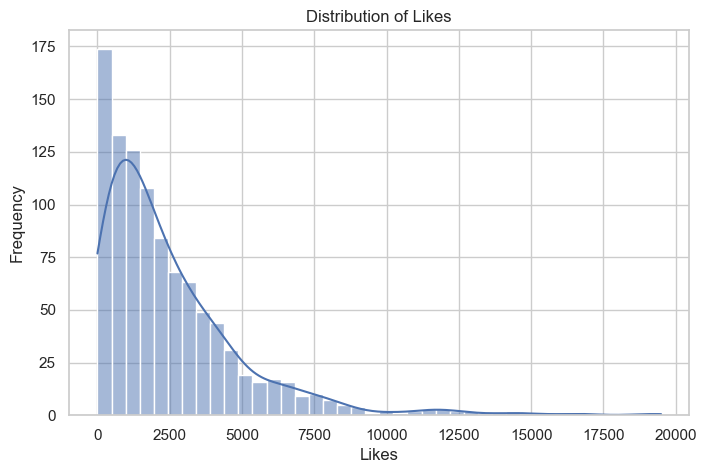

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(data["likes"], bins=40, kde=True)
plt.title("Distribution of Likes")
plt.xlabel("Likes")
plt.ylabel("Frequency")
plt.show()

#### Adjustment to the log transformation

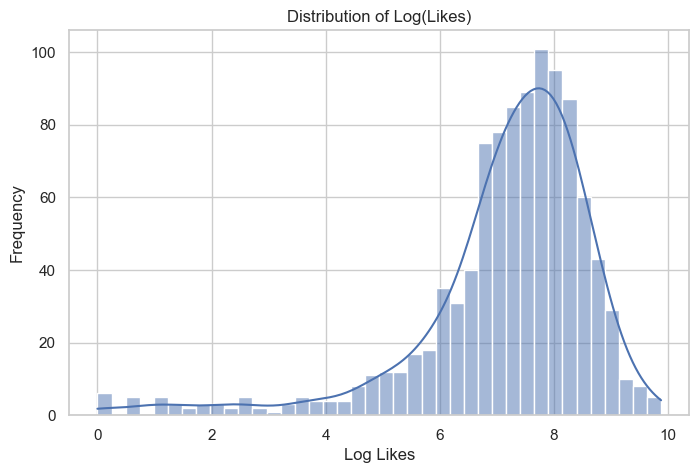

In [7]:
data["log_likes"] = np.log1p(data["likes"])

plt.figure(figsize=(8,5))
sns.histplot(data["log_likes"], bins=40, kde=True)
plt.title("Distribution of Log(Likes)")
plt.xlabel("Log Likes")
plt.ylabel("Frequency")
plt.show()

## Features Analysis

In [8]:
features = ["brightness", "sharpness", "width", "height"]
print(data[features].describe())

        brightness     sharpness        width        height
count  1006.000000   1006.000000  1006.000000   1006.000000
mean    108.797560    876.361001  4482.385686   3919.869781
std      45.950482   1254.770640  1429.440844   1295.141145
min      14.353251      2.155268  1438.000000   1218.000000
25%      76.086302    116.471036  3437.250000   3071.250000
50%     107.305622    399.897226  4272.000000   3744.000000
75%     135.750336   1152.450318  5472.000000   4634.500000
max     250.589340  11482.932958  9504.000000  12247.000000


#### Brightness Distribution

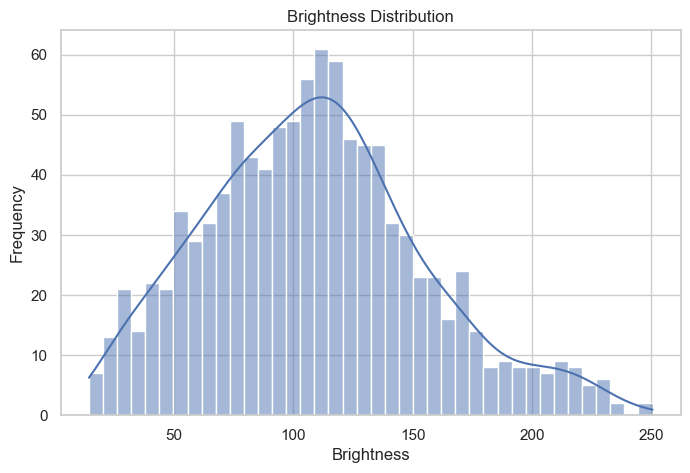

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data["brightness"], bins=40, kde=True)

plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")

plt.show()

#### Sharpness Distribution

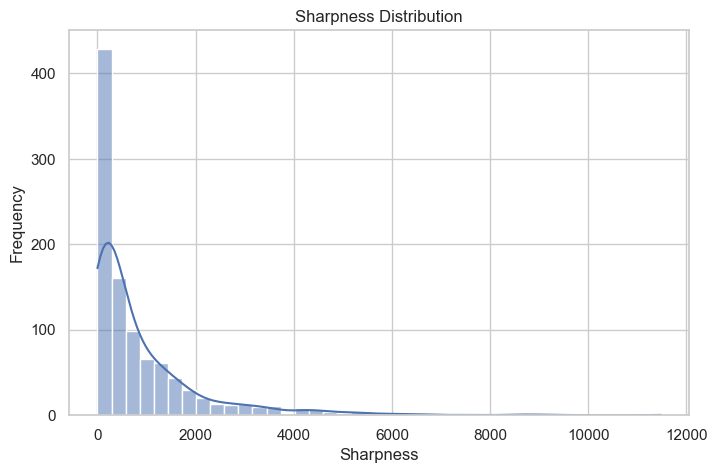

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data["sharpness"], bins=40, kde=True)

plt.title("Sharpness Distribution")
plt.xlabel("Sharpness")
plt.ylabel("Frequency")

plt.show()


#### Dimensions Distribution

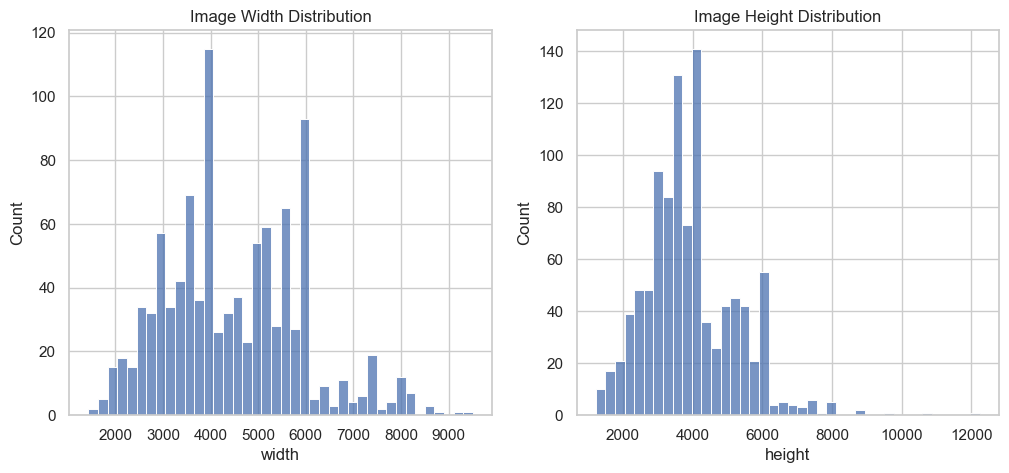

In [11]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(data["width"], bins=40, ax=axes[0])
axes[0].set_title("Image Width Distribution")

sns.histplot(data["height"], bins=40, ax=axes[1])
axes[1].set_title("Image Height Distribution")

plt.show()


#### Orientation Distribution

In [12]:
data["aspect_ratio"] = data["width"] / data["height"]

data["orientation"] = np.where(
    data["height"] > data["width"],
    "portrait",
    np.where(data["width"] > data["height"], "landscape", "square")
)

print(data["orientation"].value_counts())



orientation
landscape    649
portrait     344
square        13
Name: count, dtype: int64


## Correlation between Visual Features and Engagement

#### Brightness vs Engagement

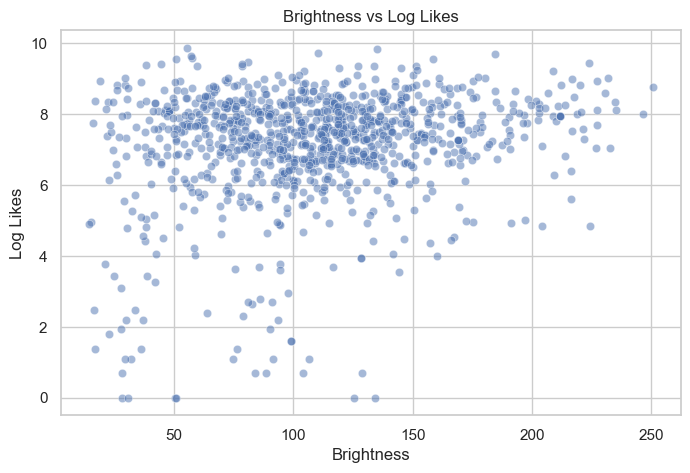

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x="brightness", y="log_likes", alpha=0.5)

plt.title("Brightness vs Log Likes")
plt.xlabel("Brightness")
plt.ylabel("Log Likes")

plt.show()

#### Sharpness vs Engagement

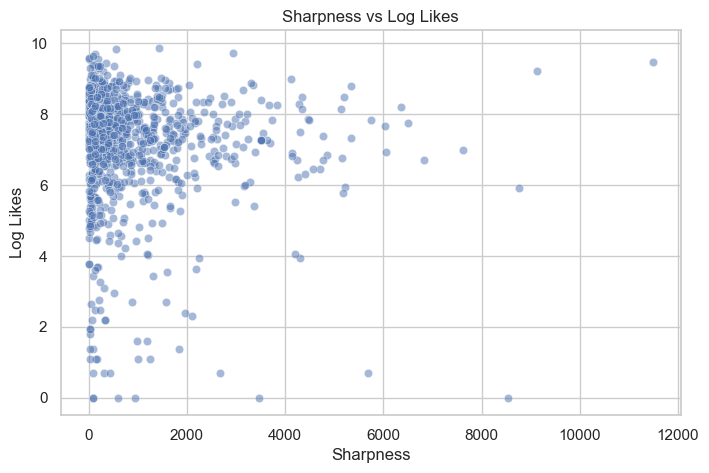

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x="sharpness", y="log_likes", alpha=0.5)

plt.title("Sharpness vs Log Likes")
plt.xlabel("Sharpness")
plt.ylabel("Log Likes")

plt.show()

#### Orientation vs Engagement

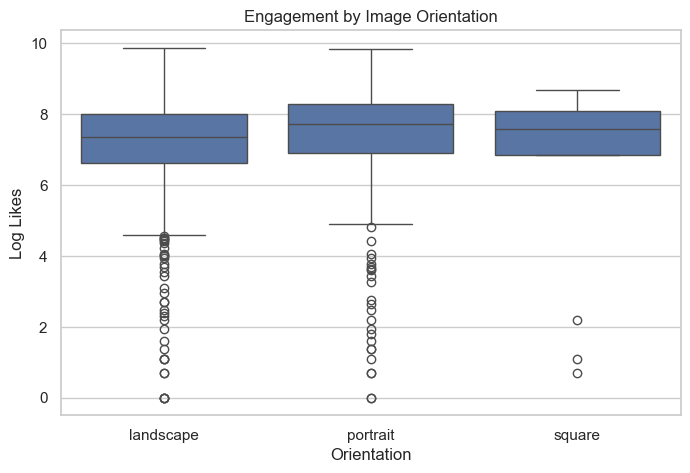

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="orientation", y="log_likes")

plt.title("Engagement by Image Orientation")
plt.xlabel("Orientation")
plt.ylabel("Log Likes")

plt.show()

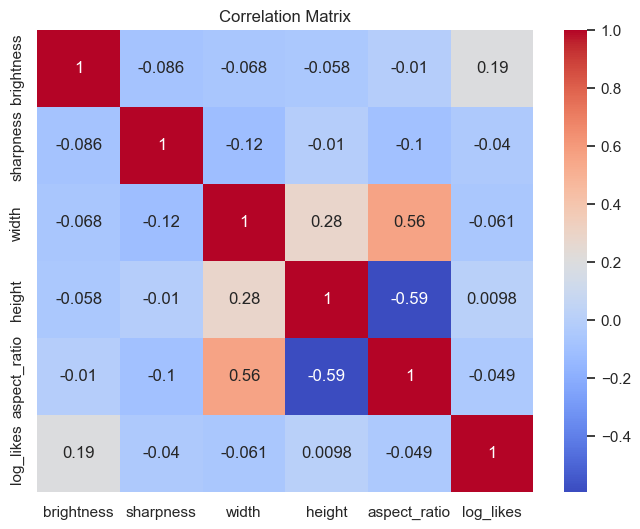

In [16]:
numeric_cols = ["brightness", "sharpness", "width", "height", "aspect_ratio", "log_likes"]

corr = data[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

## Color Analysis

In [17]:
data["color"].head(10)
data["color"].nunique()
data["color"].isna().sum()

0

#### Tansform HEX in RGB

In [18]:
import matplotlib.colors as mcolors

def hex_to_rgb(hex_color):
    try:
        return mcolors.to_rgb(hex_color)
    except:
        return (np.nan, np.nan, np.nan)

data["rgb"] = data["color"].apply(hex_to_rgb)

#### Divide RGB Colors

In [19]:
data["r"] = data["rgb"].apply(lambda x: x[0])
data["g"] = data["rgb"].apply(lambda x: x[1])
data["b"] = data["rgb"].apply(lambda x: x[2])

#### Identify Relevant color

In [20]:
def dominant_color_category(row):
    r, g, b = row["r"], row["g"], row["b"]
    
    if pd.isna(r) or pd.isna(g) or pd.isna(b):
        return "unknown"
    
    max_val = max(r, g, b)
    min_val = min(r, g, b)
    
    # grayscale cases
    if max_val - min_val < 0.1:
        if max_val < 0.2:
            return "black"
        elif max_val > 0.8:
            return "white"
        else:
            return "gray"
    
    if r > g and r > b:
        return "red"
    elif g > r and g > b:
        return "green"
    elif b > r and b > r:
        return "blue"
    else:
        return "other"

data["dominant_color"] = data.apply(dominant_color_category, axis=1)

#### Dominant Colors Distribution

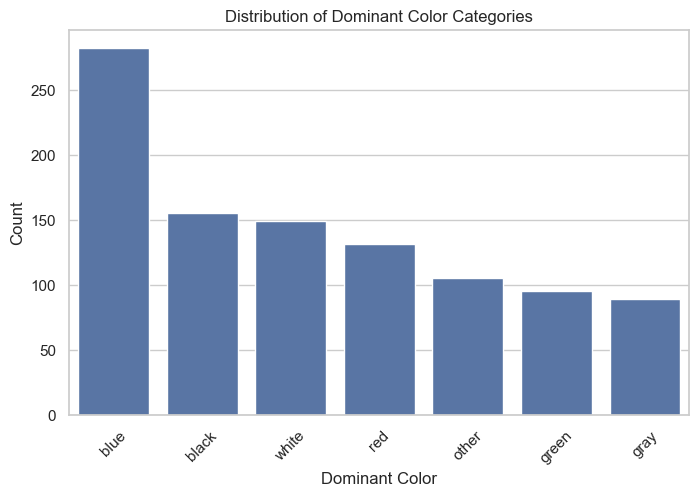

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="dominant_color", order=data["dominant_color"].value_counts().index)
plt.title("Distribution of Dominant Color Categories")
plt.xlabel("Dominant Color")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [22]:
color_performance = (
    data.groupby("dominant_color")["log_likes"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print(color_performance)

                    mean    median  count
dominant_color                           
blue            7.448548  7.698017    282
white           7.440147  7.630461    149
gray            7.246087  7.622664     89
red             7.150780  7.475906    131
black           7.045244  7.344719    155
other           6.923704  7.324490    105
green           6.226122  6.905753     95


## Time Analysis

In [23]:
data.columns

Index(['id', 'created_at', 'width', 'height', 'likes', 'color',
       'alt_description', 'username', 'image_url', 'brightness', 'sharpness',
       'log_likes', 'aspect_ratio', 'orientation', 'rgb', 'r', 'g', 'b',
       'dominant_color'],
      dtype='object')

In [24]:
data["created_at"] = pd.to_datetime(data["created_at"], errors="coerce")

In [25]:
data["year"] = data["created_at"].dt.year
data["month"] = data["created_at"].dt.month
data["month_name"] = data["created_at"].dt.month_name()
data["day_of_week"] = data["created_at"].dt.day_name()
data["hour"] = data["created_at"].dt.hour

#### Engagement by Year

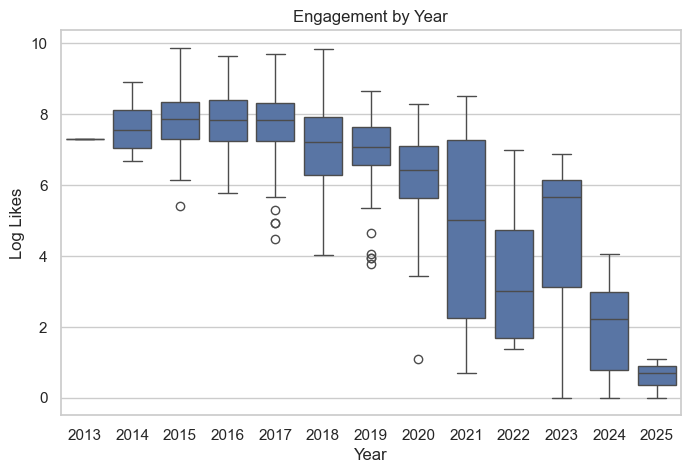

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="year", y="log_likes")
plt.title("Engagement by Year")
plt.xlabel("Year")
plt.ylabel("Log Likes")
plt.show()

#### Engagement by Month

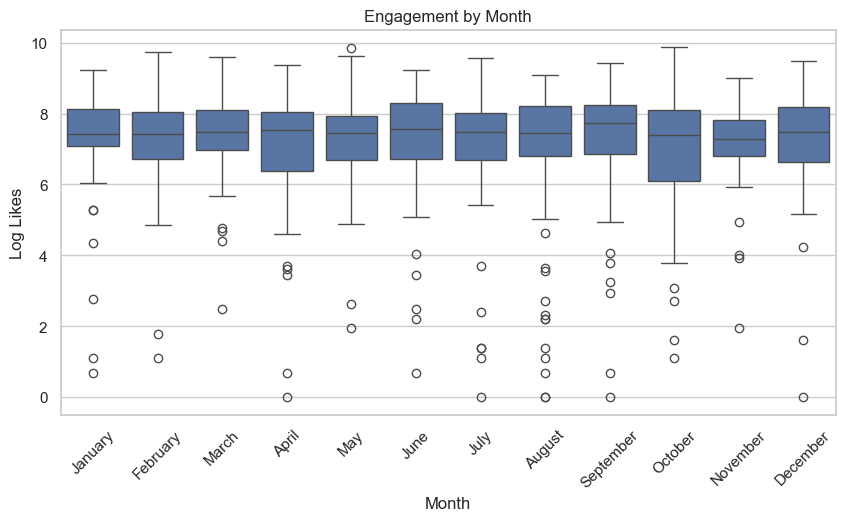

In [27]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

plt.figure(figsize=(10,5))
sns.boxplot(data=data, x="month_name", y="log_likes", order=month_order)
plt.title("Engagement by Month")
plt.xlabel("Month")
plt.ylabel("Log Likes")
plt.xticks(rotation=45)
plt.show()

#### Engagement by Day 

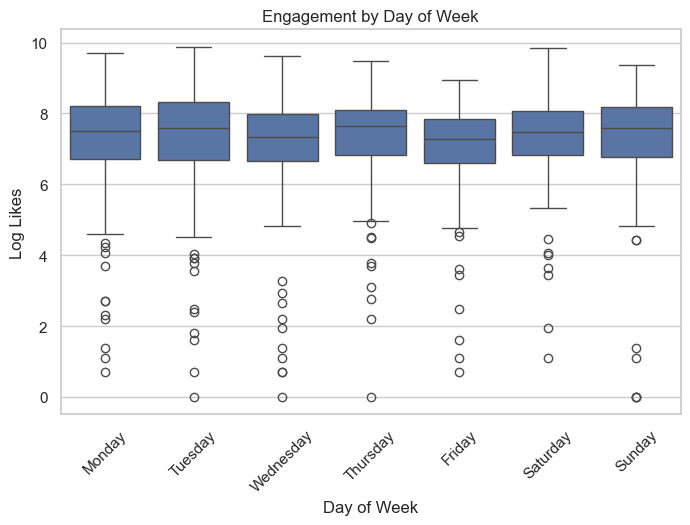

In [28]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8,5))
sns.boxplot(data=data, x="day_of_week", y="log_likes", order=day_order)
plt.title("Engagement by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Log Likes")
plt.xticks(rotation=45)
plt.show()

#### Engagement by Hours

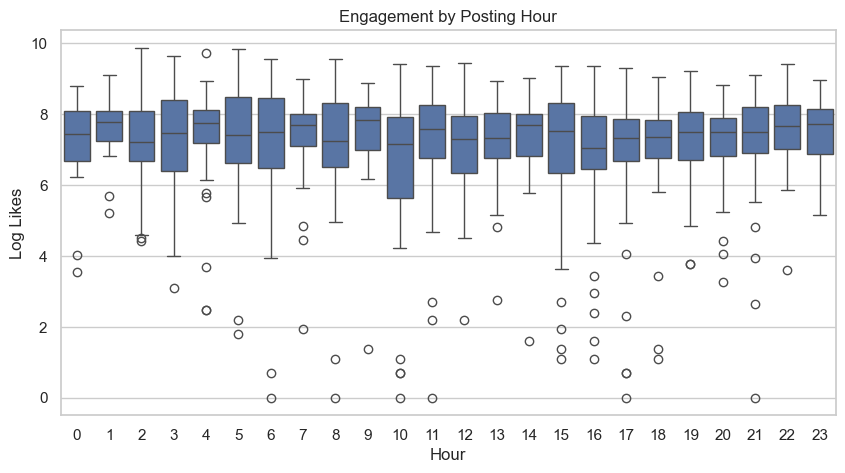

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data, x="hour", y="log_likes")
plt.title("Engagement by Posting Hour")
plt.xlabel("Hour")
plt.ylabel("Log Likes")
plt.show()

C:\Users\elham\AppData\Local\Temp\ipykernel_20732\3391619843.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data.groupby(data["created_at"].dt.to_period("M"))["log_likes"]


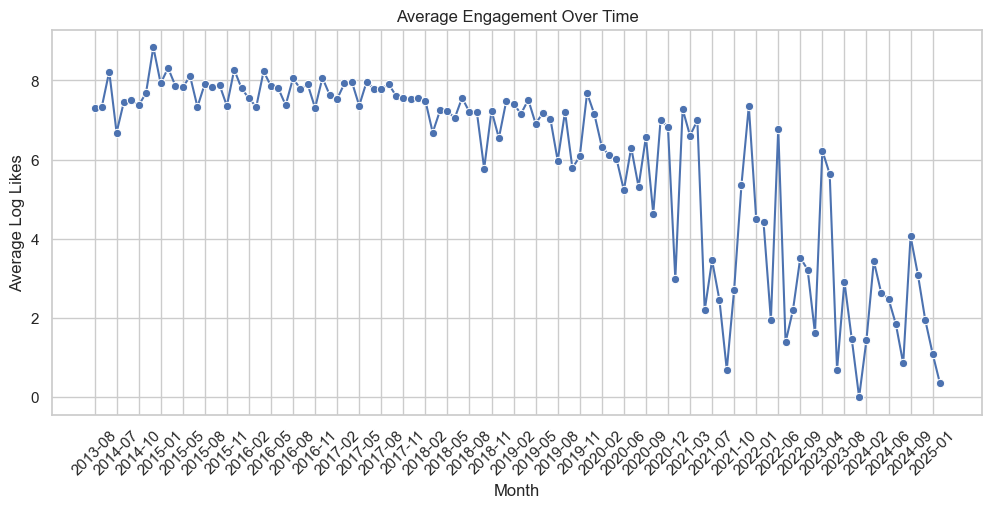

In [30]:
monthly_trend = (
    data.groupby(data["created_at"].dt.to_period("M"))["log_likes"]
    .mean()
    .reset_index()
)

monthly_trend["created_at"] = monthly_trend["created_at"].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_trend, x="created_at", y="log_likes", marker="o")

plt.title("Average Engagement Over Time")
plt.xlabel("Month")
plt.ylabel("Average Log Likes")

# show one label every 3 months
plt.xticks(
    ticks=range(0, len(monthly_trend), 3),
    labels=monthly_trend["created_at"][::3],
    rotation=45
)

plt.show()

#### Number of images over time may influence the engagement trend

C:\Users\elham\AppData\Local\Temp\ipykernel_20732\2000325354.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data.groupby(data["created_at"].dt.to_period("M"))["log_likes"]


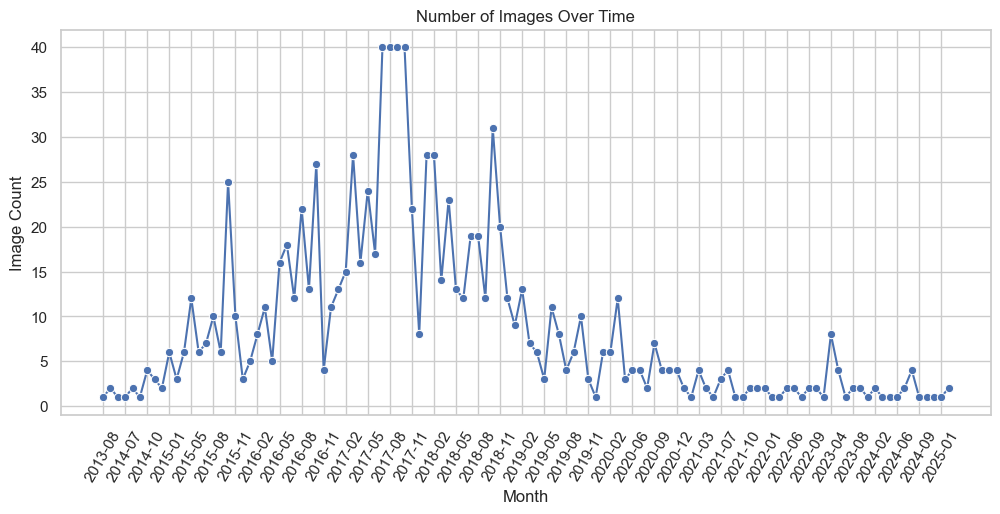

In [31]:
monthly_count = (
    data.groupby(data["created_at"].dt.to_period("M"))["log_likes"]
    .count()
    .reset_index(name="image_count")
)

monthly_count["created_at"] = monthly_count["created_at"].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_count, x="created_at", y="image_count", marker="o")
plt.title("Number of Images Over Time")
plt.xlabel("Month")
plt.ylabel("Image Count")
plt.xticks(
    ticks=range(0, len(monthly_count), 3),
    labels=monthly_count["created_at"][::3],
    rotation=60
)
plt.show()

#### Most reliable years
- To reduce noise and improve the reliability of the time-based analysis, the temporal trend was restricted to the period 2016–2018, which contains the highest concentration of images in the dataset. This allows the analysis to focus on a more stable and representative sample.

created_at
2016    152
2017    303
2018    231
Name: count, dtype: int64


C:\Users\elham\AppData\Local\Temp\ipykernel_20732\2693438738.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data_2016_2018.groupby(data_2016_2018["created_at"].dt.to_period("M"))["log_likes"]


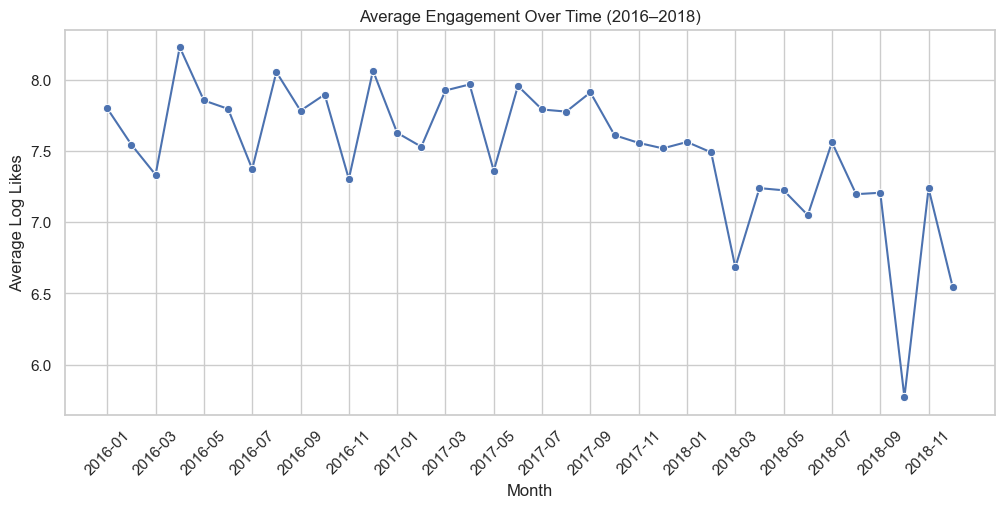

In [32]:
data_2016_2018 = data[
    (data["created_at"].dt.year >= 2016) & (data["created_at"].dt.year <= 2018)
].copy()

print(data_2016_2018["created_at"].dt.year.value_counts().sort_index())

monthly_trend_filtered = (
    data_2016_2018.groupby(data_2016_2018["created_at"].dt.to_period("M"))["log_likes"]
    .mean()
    .reset_index()
)

monthly_trend_filtered["created_at"] = monthly_trend_filtered["created_at"].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_trend_filtered, x="created_at", y="log_likes", marker="o")

plt.title("Average Engagement Over Time (2016–2018)")
plt.xlabel("Month")
plt.ylabel("Average Log Likes")

plt.xticks(
    ticks=range(0, len(monthly_trend_filtered), 2),
    labels=monthly_trend_filtered["created_at"][::2],
    rotation=45
)

plt.show()